<img src='./Images/idealized_flood_guard.jpeg' style='width: 100%; height: 400px; object-fit: cover;' />

---
<h1 align='center'>
NAIROBI FLOOD GUARD
</h1>

> **Authors**: Group 4

---

<h2 align='center'>
1. INTRODUCTION
</h2>

### Overview

Nairobi Flood Guard is a data science project that addresses the growing threat of flooding across Kenya. Motivated by the devastating April 2024 floods and the recent 2026 floods that disrupted lives across the country, the project aims to shift flood response from reactive to predictive.

The project has two components:

- The first is a **flood susceptibility model** that combines NASA SRTM terrain data and CHIRPS satellite rainfall data to predict which of Kenya's 1,450 administrative ward are most at risk of flooding, trained on UNOSAT satellite-derived flood extent data from the April 2024 event.

- The second is a **matatu route optimization system** that overlays floods risk predictions against Nairobi's public transport network to identify affected routes and recommend safer alternatives for operators and commuters.

Built entirely on open data and reproducible tools, Nairobi Flood Guard gives communities, emergency responders, and transport operations the advance information they need to act before a flood, not after.

### Business Understanding

#### *Problem Statement*

Flooding in Nairobi and Kenya at large causes loss of life, displacement and infrastructure damage. The April 2024 floods killed over 200 people and displaced hundreds of thousands. Current flood response is largely reactive rather than predictive. There is no system that warns communities or road users in advance.

#### *Objectives*

- **Flood Susceptibility Prediction** - identify which wards are at highest risk of flooding given terrain and rainfall conditions

- **Matatu Route Optimization** - given predicted flood zones, identify affected matatu routes and recommend safer alternatives

#### *Stakeholders*

- **Kenya Red Cross / National Disaster Management Unit** - early warning for evacuation planning

- **Nairobi City County** - infrastructure and emergency response

- **Matatu operators and SACCOs** - route planning during flood events

- **Commuters** - real-time route guidance

- **General public in flood-prone wards** - advance warning to evacuate or prepare

#### *Success Metrics*

- **Recall** is the primary metric - missing a flood (false negative) is far more costly than a false alarm

- Route recommendations that successfully avoid confirmed flood zones from UNOSAT data

- Ward-level risk scores that align with known historically flooded areas

#### *Scope and Limitations*

- Labels are based on a **single flood event** (April 2024) - the model may not generalise to floods caused by different conditions

- GTFS data is from **2019** - the matatu network may have changed

- Ward-level predictions are coarse - a ward may be partially flooded but the whole ward gets labelled as flooded

- The model predicts **susceptibility** not exact flood timing or depth

---

<h2 align='center'>
2. DATA UNDERSTANDING
</h2>

This project utilises five datasets, each contributing a different dimension to the flood prediction and route optimization pipeline. Below is an overview of each dataset, followed by an exploratory examination of the compiled feature matrix

### a) SRTM Digital Elevation Model (DEM)

The Shuttle Radar Topography Mission (SRTM) DEM, acquired by NASA in 2000, provides elevation data at 90 metre resolution. It was used to derive three terrain features per ward: mean elevation, minimum elevation, maximum elevation, and slope. These features capture how water naturally flows and accumulates across the landscape.

**Source:** OpenTopography (SRTM GL3 product)

### b) CHIRPS Rainfall Data

The Climate Hazards Group InfraRed Precipitation with Station data (CHIRPS) provides daily rainfall estimates at approximately 5km resolution. Ninety daily rasters covering February–April 2024 were used to derive three rainfall features per ward: cumulative rainfall, maximum single-day rainfall, and total rainfall in the seven days preceding the April 26 flood event.

**Source:** UCSB Climate Hazards Group

### c) UNOSAT Flood Extent - FL20240426KEN

A satellite-derived flood extent geodatabase produced by UNOSAT following the April 2024 Kenya floods. The Kenya-wide maximum flood water extent polygon was used to generate binary flood labels for each ward — flooded (1) or not flooded (0).

**Source:** UNOSAT / UNITAR

### d) Kenya Wards Shapefile

A polygon shapefile of Kenya's 1450 administrative wards including ward name, sub-county, county, and 2009 census population. This served as the spatial backbone of the project - all raster datasets were aggregated to ward level through spatial joins and zonal statistics.

**Source:** Regional Centre for Mapping of Resources for Development (RGMRD)

### e) GTFS Feed 2019 - Nairobi Matatu Network

A General Transit Feed Specification (GTFS) dataset describing Nairobi's matatu public transport network as of 2019, including 136 routes, 4,284 stops, and 36,483 route shape points. This dataset underpins the route optimization component of the project.

**Source:** Digital Matatus Project

### f) Compiled Feature Matrix - floods.gpkg

All datasets were processed and merged into a single GeoPackage file (`floods.gpkg`) containing one row per ward with all features and the flood label. More information about about the compiled feature matrix can be found [here](./Data/floods_description.md). The cells below examine this compiled dataset.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = gpd.read_file('./Data/floods.gpkg')
df.head()

,ward,subcounty,county,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg,geometry
0,WABERA,Isiolo Sub County,ISIOLO,17431.0,0,0.000000,0.000000,0.000000,1099.219448,1026.0,1177.0,1.413028,"MULTIPOLYGON (((37.59968 0.40029, 37.59976 0.4..."
1,North Kamagambo Ward,Rongo Sub County,Migori,18755.0,0,258.608840,14.135786,39.955728,1405.549444,1350.0,1508.0,2.246821,"MULTIPOLYGON (((34.59938 -0.65054, 34.60006 -0..."
2,Central Kamagambo Ward,Rongo Sub County,Migori,27756.0,0,125.951383,8.779010,20.537484,1462.532567,1387.0,1534.0,3.392240,"MULTIPOLYGON (((34.61175 -0.73357, 34.61183 -0..."
3,South Kamagambo Ward,Rongo Sub County,Migori,27179.0,0,45.941367,5.696220,10.762588,1490.546337,1363.0,1638.0,4.263301,"MULTIPOLYGON (((34.61751 -0.87293, 34.6175 -0...."
4,North Sakwa Ward,Awendo Sub County,Migori,22874.0,0,78.351185,4.580237,10.795914,1376.935386,1287.0,1617.0,3.834336,"MULTIPOLYGON (((34.55349 -0.75193, 34.55364 -0..."


In [2]:
# Shape and data types
df.info() 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   object  
 1   subcounty            1450 non-null   object  
 2   county               1450 non-null   object  
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
dtypes: float64(8), geometry(1), int64(1), object(3)
memory usage: 147.4+ KB


In [3]:
# Summary statistics
df.drop(columns='geometry').describe()

,pop2009,flooded,rain_cumulative_mm,rain_max_daily_mm,rain_preflood_7d_mm,elevation_mean_m,elevation_min_m,elevation_max_m,slope_mean_deg
count,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000,1450.000000
mean,26627.057241,0.211724,117.304138,12.532226,18.302685,1382.455583,1202.211724,1678.705517,4.289460
std,9885.965260,0.408671,88.315044,10.741149,15.934685,643.397070,594.786452,771.792365,2.937476
min,1052.000000,0.000000,0.000000,0.000000,0.000000,5.834231,-15.000000,17.000000,0.507857
25%,20035.500000,0.000000,66.325468,5.626600,8.659686,1130.018716,834.750000,1353.500000,2.039088
50%,25794.000000,0.000000,108.482319,9.961980,15.676050,1487.725496,1314.000000,1691.000000,3.662881
75%,32287.250000,0.000000,154.867987,17.015787,25.332106,1815.967362,1628.000000,2083.250000,5.744822
max,75270.000000,1.000000,735.989837,81.359943,145.566664,2969.985544,2573.000000,5036.000000,18.207465


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ward                   0
subcounty              0
county                 0
pop2009                0
flooded                0
rain_cumulative_mm     0
rain_max_daily_mm      0
rain_preflood_7d_mm    0
elevation_mean_m       0
elevation_min_m        0
elevation_max_m        0
slope_mean_deg         0
geometry               0
dtype: int64


In [5]:
# Create a derived feature elevation range
df['elevation_range_m'] = df['elevation_max_m'] - df['elevation_min_m']
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ward                 1450 non-null   object  
 1   subcounty            1450 non-null   object  
 2   county               1450 non-null   object  
 3   pop2009              1450 non-null   float64 
 4   flooded              1450 non-null   int64   
 5   rain_cumulative_mm   1450 non-null   float64 
 6   rain_max_daily_mm    1450 non-null   float64 
 7   rain_preflood_7d_mm  1450 non-null   float64 
 8   elevation_mean_m     1450 non-null   float64 
 9   elevation_min_m      1450 non-null   float64 
 10  elevation_max_m      1450 non-null   float64 
 11  slope_mean_deg       1450 non-null   float64 
 12  geometry             1450 non-null   geometry
 13  elevation_range_m    1450 non-null   float64 
dtypes: float64(9), geometry(1), int64(1), object(3)
memory usage: 15

In [6]:
# Class distribution
print("Flood label distribution:")
print(df['flooded'].value_counts())
print(f"\nFlooded wards    : {df['flooded'].sum()} ({df['flooded'].mean()*100:.1f}%)")
print(f"Non-flooded wards: {(df['flooded']==0).sum()} ({(1-df['flooded'].mean())*100:.1f}%)")

Flood label distribution:
flooded
0    1143
1     307
Name: count, dtype: int64

Flooded wards    : 307 (21.2%)
Non-flooded wards: 1143 (78.8%)


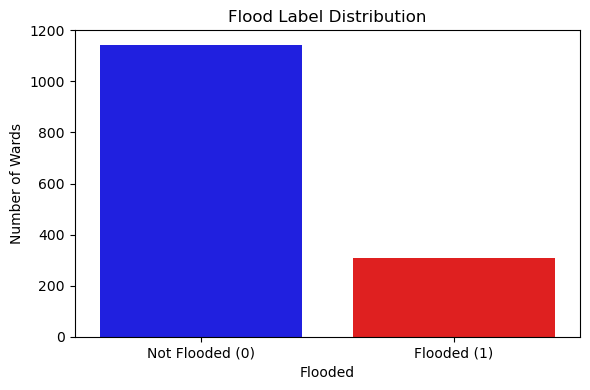

In [7]:
# Visualize class imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(
    x='flooded',
    data=df,
    hue='flooded',
    palette={0: '#0000FF', 1: '#FF0000'},
    legend=False,
    ax=ax
)
ax.set_title('Flood Label Distribution')
ax.set_xlabel('Flooded')
ax.set_ylabel('Number of Wards')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Flooded (0)', 'Flooded (1)'])
plt.tight_layout()
plt.show()

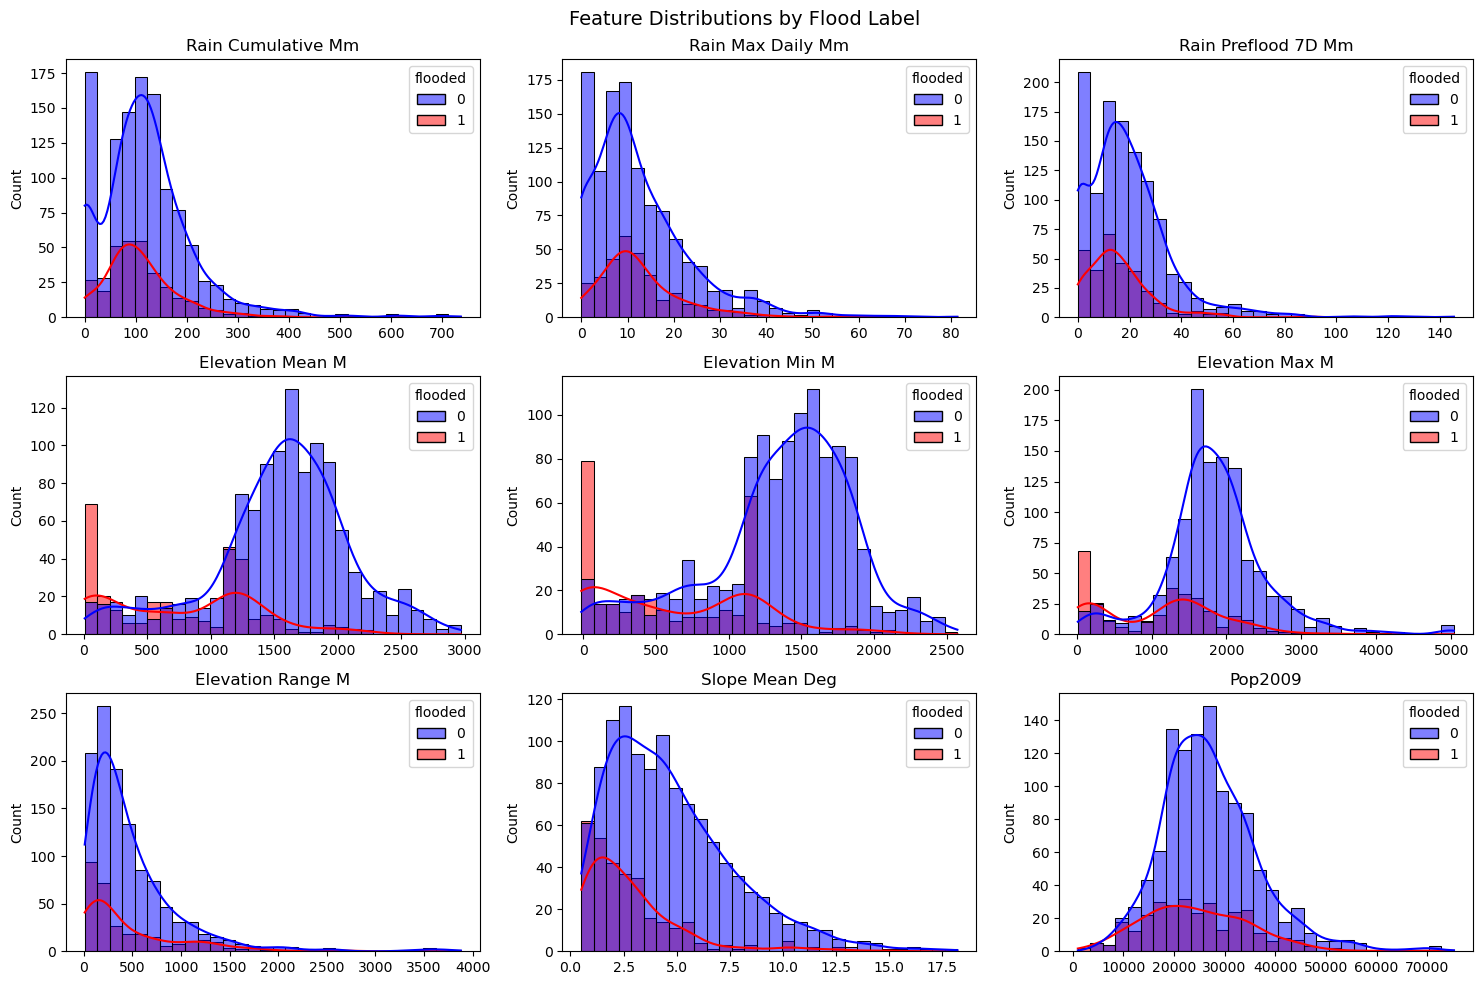

In [8]:
# Feature distributions
feature_cols = [
    'rain_cumulative_mm', 'rain_max_daily_mm', 'rain_preflood_7d_mm',
    'elevation_mean_m', 'elevation_min_m', 'elevation_max_m',
    'elevation_range_m', 'slope_mean_deg', 'pop2009'
]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(feature_cols):
    ax = axs.flatten()[i]
    sns.histplot(data=df, x=col, hue='flooded', kde=True,
                 palette={0: '#0000FF', 1: '#FF0000'}, ax=ax, bins=30)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')

fig.suptitle('Feature Distributions by Flood Label', fontsize=14)
plt.tight_layout()
plt.show()

The feature distribution plots reveal that flooded wards receive less rainfall than non-flooded ones — suggesting that at ward scale, rainfall intensity is a weak standalone predictor of flooding in Kenya. The elevation distributions show the clearest separation, with flooded wards sitting nearly 800m lower on average than non-flooded ones, confirming that low-lying terrain is the dominant flood risk factor.

Slope distributions reinforce this — flooded wards are consistently flatter, meaning water accumulates rather than drains. Elevation range shows almost no difference between flooded and non-flooded wards, making it the least informative feature visually. Population distributions overlap heavily between the two classes, offering only a marginal signal. Not surpisingly, areas that tend to have flooding are less populated compared to areas that do not suffer from severe floods

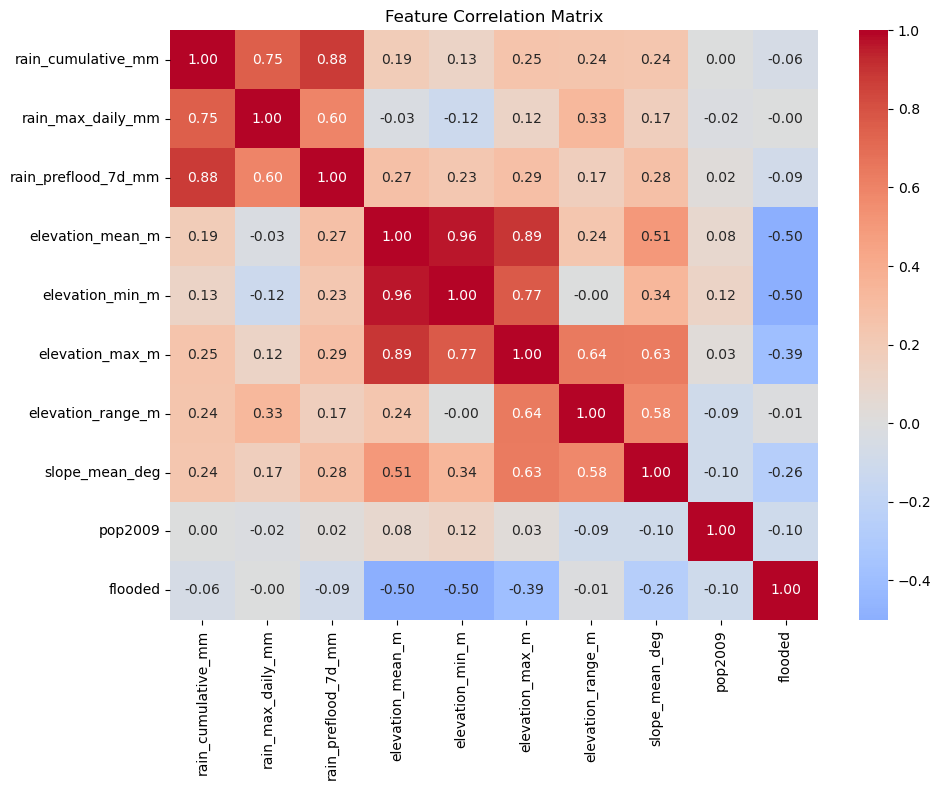

In [9]:
# Correlation heatmap
corr = df[feature_cols + ['flooded']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation heatmap confirms the previous observations quantitatively. Elevation features dominate - `elevation_min_m` and `elevation_mean_m` carry the strongest negative correlations with flooding (-0.50 and -0.50 respectively), followed by `elevation_max_m` (-0.39) and `slope_mean_deg` (-0.26).

All rainfall features correlate weakly with flooding, with `rain_max_daily_mm` showing virtually no linear relationship (-0.001). The heatmap also reveals high inter-correlation between the three elevation features, meaning they carry overlapping information — something the model will need to handle.

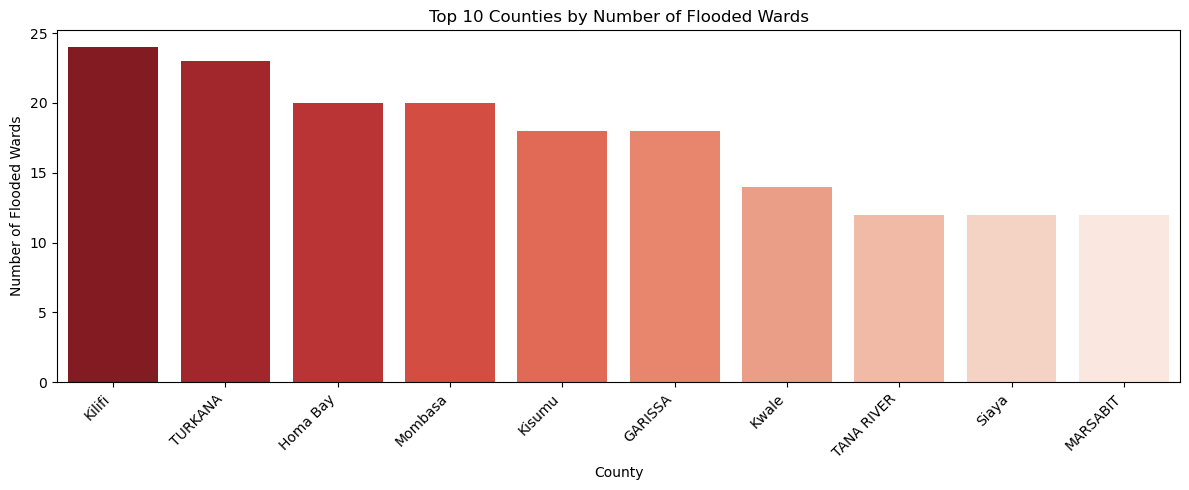

In [10]:
# Top 10 most flooded counties
county_flood = df.groupby('county')['flooded'].agg(['sum', 'count'])
county_flood.columns = ['flooded_wards', 'total_wards']
county_flood['flood_rate'] = county_flood['flooded_wards'] / county_flood['total_wards']
county_flood = county_flood.sort_values('flooded_wards', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=county_flood.index, y='flooded_wards', hue=county_flood.index, data=county_flood,
            palette='Reds_r', ax=ax, legend=False)
ax.set_title('Top 10 Counties by Number of Flooded Wards')
ax.set_xlabel('County')
ax.set_ylabel('Number of Flooded Wards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### *Key Takeaway*

The dataset reveals that in Kenya, flooding is primarily a terrain-driven phenomenon at the ward scale. Low-lying wards flood not necessarily because they receive more rain, but because water from surrounding higher ground drains into them. This has implications for the model - terrain features will dominate predictions, and rainfall adds marginal value at this spatial scale.

---

<h2 align='center'>
3. MODEL BUILDING AND EVALUATION
</h2>

Four classification model families were independently developed and tuned by the project team, each in its own dedicated notebook located in the `Model/Notebooks/` directory:

 a) [Logistic Regression](./Models/Notebooks/logistic_notebook.ipynb) (baseline) - saved [here](./Models/best_log_reg_model.pkl)

 b) [Random Forest Classifier](./Models/Notebooks/random_forest_notebook.ipynb) - saved [here](./Models/best_random_forest_model.pkl)

 c) [XGBoost Classifier](./Models/Notebooks/XGBoost_notebook.ipynb) - saved [here](./Models/best_xg_boost_model.pkl)

 d) [Neural Network](./Models/Notebooks/neural_notebook.ipynb) - saved [here](./Models/best_neural_model.keras)


Each model was iteratively improved through hyperparameter tuning, regularisation, and class imbalance handling before the best version was saved. This notebook loads those best models and evaluates them on a shared held-out test set to determine the overall best performer.

Given the nature of this problem - predicting which wards are at risk of flooding - **recall is the primary evaluation metric**. A missed flood prediction (false negative) carries far greater consequences than a false alarm (false positive). Secondary metrics used for comparison are AUC, F1-score, precision, and accuracy.

In [11]:
# Imports and data loading
import joblib
import pandas as pd
import pickle
import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, auc, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Neural Network model
nn_model = keras.models.load_model('./Models/best_neural_model.keras')

# Logistic Regression Model
with open('./Models/best_logistic_model.pkl', 'rb') as f:
    logistic_model = pickle.load(f)

# Random Forest Model
rf_model = joblib.load('./Models/best_random_forest_model.pkl')

# XGBoost
with open('./Models/best_xg_boost_model.pkl', 'rb') as f:
    xg_boost_model = pickle.load(f)

I0000 00:00:1778661464.526696  528037 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1778661467.855704  528200 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778661468.232084  528037 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Preprocessing

In this section, the data stored in `df` will be split into the features, `X` and target, `y`, and a standard train-test split will be performed.

Each of the models was trained on scaled features, thus, the features will be scaled using `StandardScaler` before being fed into the models.

Due to the limited size of the dataset, no validation data will be created.

In [12]:
X = df[feature_cols]
y = df['flooded']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=2026)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1015 entries, 454 to 845
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rain_cumulative_mm   1015 non-null   float64
 1   rain_max_daily_mm    1015 non-null   float64
 2   rain_preflood_7d_mm  1015 non-null   float64
 3   elevation_mean_m     1015 non-null   float64
 4   elevation_min_m      1015 non-null   float64
 5   elevation_max_m      1015 non-null   float64
 6   elevation_range_m    1015 non-null   float64
 7   slope_mean_deg       1015 non-null   float64
 8   pop2009              1015 non-null   float64
dtypes: float64(9)
memory usage: 79.3 KB


### a) Logistic Regression (baseline)

Logistic Regression serves as the baseline model for this project. As a linear classifier, it provides a performance floor that all other models should exceed. It was trained with `class_weight='balanced'` to account for the 21/79 class imbalance, and scaled features were passed through a `StandardScaler` pipeline. The confusion matrix below shows how well it identifies flooded wards on the held-out test set.

In [13]:
log_reg_pipeline = Pipeline(
    [
        ('StandardScaler', StandardScaler()),
        ('log_reg_model', logistic_model)
    ]
)

log_reg_pipeline.fit(X_train, y_train)

# Helper function to calculate metrics
def get_metrics_df(pipeline, name, X_test=X_test, y_test=y_test):
    """
    NB: This function takes a fitted pipeline
    """
    metrics_dict = {}
    metrics_dict['Model'] = name
    preds = pipeline.predict(X_test)
    probas = pipeline.predict_proba(X_test)[:, 1]

    # Get roc score
    metrics_dict['AUC'] = [roc_auc_score(y_test, probas)]

    # Use the macro_avg scores
    classification_dict = classification_report(y_test, preds, output_dict=True)
    metrics_dict['accuracy'] = [classification_dict['accuracy']]

    for key, value in classification_dict['macro avg'].items():
        metrics_dict[key] = [value]
    
    # Return metrics as a pandas dataframe
    return pd.DataFrame(metrics_dict)

In [14]:
# Display metrics for the logistic model as a dataframe
logistic_df = get_metrics_df(log_reg_pipeline, "Logistic")
logistic_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Logistic,0.834707,0.765517,0.691354,0.755863,0.705018,435.0


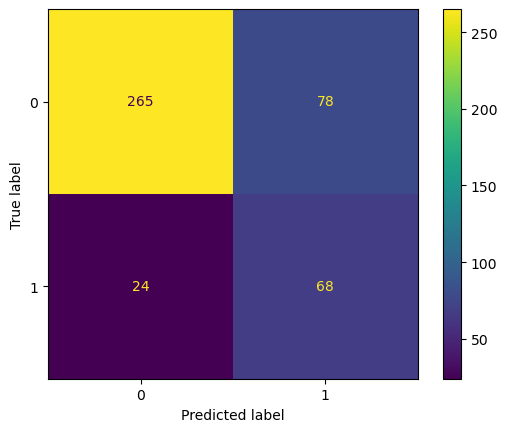

In [15]:
display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, log_reg_pipeline.predict(X_test))
)
display.plot()
plt.show()

The baseline logistic regression model does not show strong recall on the flooded class, with more than half of its predicted positives being false positives. It shows strong overall recall by keeping false negatives low. This sets a solid performance floor for the more complex models to beat.

### b) Random Forest Model

In [16]:
rf_pipeline = Pipeline(
    [
        ('StandardScaler', StandardScaler()),
        ('rf_model', rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

random_forest_df = get_metrics_df(rf_pipeline, "Random_Forest")
random_forest_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Random_Forest,0.894632,0.83908,0.763133,0.818418,0.783095,435.0


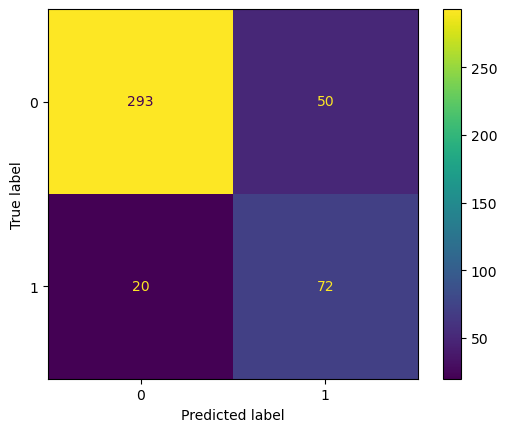

In [17]:
display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pipeline.predict(X_test))
)
display.plot()
plt.show()

The Random Forest improves on the baseline across all metrics. Its ensemble nature — aggregating predictions from many decision trees — allows it to capture non-linear relationships between terrain features and flood risk that the logistic regression cannot. It currently leads all models evaluated so far.

### c) XGBoost Classifier Model

In [18]:
xg_boost_pipeline = Pipeline(
    [
        ('StandardScaler', StandardScaler()),
        ('xg_boost_model', xg_boost_model)
    ]
)

xg_boost_pipeline.fit(X_train, y_train)

xg_boost_df = get_metrics_df(xg_boost_pipeline, "XGBoost")
xg_boost_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,XGBoost,0.875808,0.811494,0.733165,0.792971,0.752044,435.0


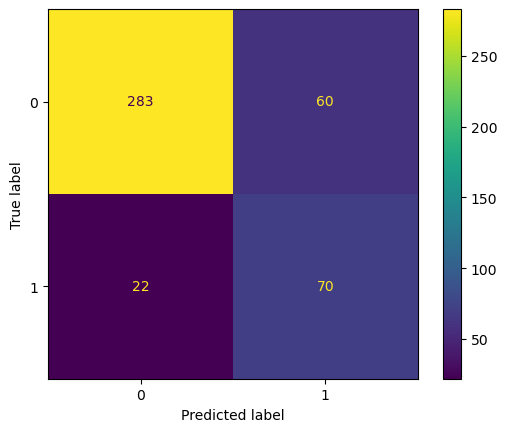

In [19]:
display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, xg_boost_pipeline.predict(X_test))
)
display.plot()
plt.show()

Although the XGBoost model underperforms slightly relative to the Random Forest on this dataset in terms of recall, it more than makes up for it with its high accuracy, precision and f1-score. This is likely attributable to its ensemble nature which, like the Random Forest, allows it to capture non-linear relationships between terrain features and flood risk

### d) Neural Network

Unlike the other models, training the neural network will destroy its saved weights. Thus, we need to specify that the model be used as is

The neural network model does not have a fit method, thus, it cannot be integrated directly into a scikit-learn pipeline. `KerasClassifier` will be used to solve this

In [20]:
compatible_nn_model = KerasClassifier(
    model=nn_model,
    epochs=0, # Specify that the 
    warm_start=True # model be used as is
)

nn_pipeline = Pipeline(
    [
        ('StandardScaler', StandardScaler()),
        ('nn_model', compatible_nn_model)
    ]
)

# Fit initialises the StandardScaler. It does not train the model
nn_pipeline.fit(X_train, y_train)

nn_model_df = get_metrics_df(nn_pipeline, "Neural_Network")
nn_model_df

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Model,AUC,accuracy,precision,recall,f1-score,support
0,Neural_Network,0.777919,0.737931,0.65103,0.694622,0.661215,435.0


 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


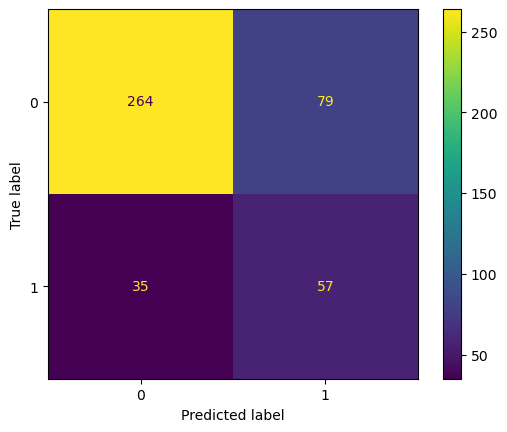

In [21]:
display = ConfusionMatrixDisplay(
    confusion_matrix(y_test, nn_pipeline.predict(X_test))
)
display.plot()
plt.show()

The Neural Network significantly underperforms relative to the Random Forest and XGBoost model. Neural networks typically require large amounts of training data to generalise well - with only 1,450 ward-level samples, the model has limited capacity to learn complex spatial patterns compared to tree-based ensembles.

### *Final Evaluation*

Comparing the metrics of all the models:

In [22]:
all_models_df = pd.concat(
    [
        logistic_df,
        nn_model_df,
        random_forest_df,
        xg_boost_df,
    ],
    axis=0,
    ignore_index=True
)
all_models_df

,Model,AUC,accuracy,precision,recall,f1-score,support
0,Logistic,0.834707,0.765517,0.691354,0.755863,0.705018,435.0
1,Neural_Network,0.777919,0.737931,0.651030,0.694622,0.661215,435.0
2,Random_Forest,0.894632,0.839080,0.763133,0.818418,0.783095,435.0
3,XGBoost,0.875808,0.811494,0.733165,0.792971,0.752044,435.0


The table below ranks all four models by recall - the primary metric:

In [23]:
all_models_df.sort_values(by='recall', ascending=False)

,Model,AUC,accuracy,precision,recall,f1-score,support
2,Random_Forest,0.894632,0.839080,0.763133,0.818418,0.783095,435.0
3,XGBoost,0.875808,0.811494,0.733165,0.792971,0.752044,435.0
0,Logistic,0.834707,0.765517,0.691354,0.755863,0.705018,435.0
1,Neural_Network,0.777919,0.737931,0.651030,0.694622,0.661215,435.0


The **Random Forest** achieves the highest recall among all four models, correctly identifying the greatest proportion of flood-prone wards. The XGBoost model, nevertheless, is a strong contender with quite high accuracy, precision and f1-score metrics of the four models.

Given that we are looking for the model with the best recall, and, combined with its competitive AUC and F1 scores, the **Random Forest** is selected as the final model for flood susceptibility prediction.

Looking at the models ROC curves:

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


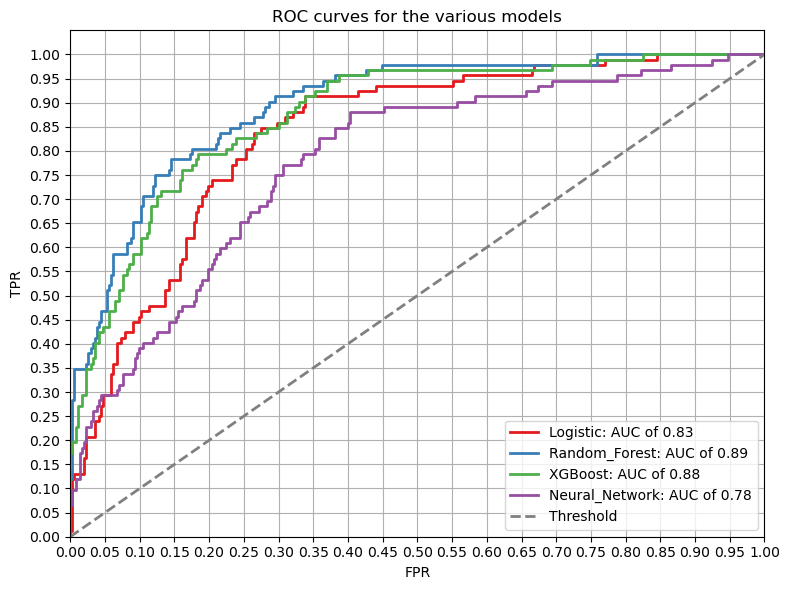

In [24]:
model_dict = {
    'Logistic': log_reg_pipeline,
    'Random_Forest': rf_pipeline,
    'XGBoost': xg_boost_pipeline,
    'Neural_Network': nn_pipeline
}
colors = sns.color_palette('Set1', len(model_dict))
plt.figure(figsize=(8, 6))

for i, (name, pipeline) in enumerate(model_dict.items()):
    fpr, tpr, thresholds = roc_curve(y_test, pipeline.predict_proba(X_test)[:, 1])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}: AUC of {auc_score:.2f}", color=colors[i], lw=2)

plt.plot([0, 1], [0, 1], label='Threshold', color='grey', linestyle='--', lw=2)

plt.grid(True)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title("ROC curves for the various models")
plt.xticks([n/20 for n in range(21)])
plt.yticks([n/20 for n in range(21)])
plt.xlim([0.0 , 1])
plt.ylim([0.0, 1.05])
plt.legend()
plt.tight_layout()
plt.show()

The **Random Forest** achieves the highest AUC of 0.90, with its curve sitting closest to the top-left corner - confirming its superior ability to rank flood-prone wards above non-flooded ones across all thresholds, not just the default 0.5. **XGBoost** follows closely at AUC 0.89 - a strong result, though its lower recall in the metrics table (0.77 vs the Random Forest's 0.81) means it misses more flood-prone wards at the default decision threshold. The **Logistic Regression** baseline achieves AUC 0.83, a solid result for a linear model and a testament to how well elevation features alone separate the two classes. The **Neural Network** records the lowest AUC of 0.79, consistent with its limited capacity to generalise on a dataset of only 1,450 samples.

Notably, all four models significantly outperform the random baseline, confirming that terrain and rainfall features carry genuine predictive signal for flood susceptibility at ward level. The ROC curves reinforce the metrics table conclusion — the **Random Forest is the best overall model**, offering the strongest discrimination between flooded and non-flooded wards when recall is prioritised.

---

<h2 align='center'>
4. ROUTE OPTIMIZATION
</h2>



In [27]:
tableau_csv = df.drop('geometry', axis=1)

tableau_csv.to_csv('./Data/tableau_csv')

print("CSV file saved!")

CSV file saved!
